# Baseline and tuning training audit

This notebook discovers classification and reconstruction logs dynamically. Completion is determined from the latest job block in each append-only log. Only a matching training finish marker with `rc=0` is included in performance summaries.

The same scanner also recognizes future `trial_000` style tuning directories. Failed, incomplete, and archived attempts remain visible in status tables but are excluded from model comparisons.

In [8]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RESULTS_ROOT = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC")
ACTIVE_TASKS = {"classification", "reconstruction"}
INCLUDE_ARCHIVED_IN_PERFORMANCE = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 120})

if not RESULTS_ROOT.is_dir():
    raise FileNotFoundError(RESULTS_ROOT)

RESULTS_ROOT

PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC')

## Log parser

Logs are written with append mode, so an old successful marker is not sufficient. The parser finds the final `HOST` line and evaluates only the job block that follows it.

In [9]:
HOST_RE = re.compile(r"^--- HOST:\s+JOB=(\d*)")
CONFIG_RE = re.compile(r"^--- CONFIG:\s*(.+?)\s*$")
FINISH_RE = re.compile(
    r"^--- (train_classification|train_reconstruction|run_inference|train_geometry_selection) "
    r"finished \(rc=(-?\d+)\)\s*$"
)
TRIAL_RE = re.compile(r"(?:^|[_-])trial[_-]?(\d+)(?:$|[_-])", re.IGNORECASE)
ROUTE_CLASS_RE = re.compile(r"^class(\d+)$", re.IGNORECASE)
TARGET_RE = re.compile(r"(?:^|_)(energy|zenith|azimuth)(?:_|\.|$)", re.IGNORECASE)
ARCHIVE_TOKENS = ("failed", "cancelled", "archive", "archived", "_old", "oom")

EXPECTED_STAGE = {
    "classification": "train_classification",
    "reconstruction": "train_reconstruction",
}


def _trial_number(parts):
    for part in parts:
        match = TRIAL_RE.search(part)
        if match:
            return int(match.group(1))
    return None


def _target_from_path(path):
    for value in (path.parent.name, path.name):
        match = TARGET_RE.search(value)
        if match:
            return match.group(1).lower()
    return None


def path_metadata(log_path):
    relative = log_path.relative_to(RESULTS_ROOT)
    parts = relative.parts
    task_positions = [i for i, part in enumerate(parts) if part in ACTIVE_TASKS]
    if not task_positions:
        return None

    task_index = task_positions[0]
    task = parts[task_index]
    geometry = parts[task_index - 1] if task_index else None
    category = parts[task_index + 1] if len(parts) > task_index + 1 else None

    route_class = None
    for part in parts[task_index + 2:]:
        match = ROUTE_CLASS_RE.match(part)
        if match:
            route_class = int(match.group(1))
            break

    lower_parts = [part.lower() for part in parts]
    archived = any(token in part for part in lower_parts for token in ARCHIVE_TOKENS)
    trial_number = _trial_number(parts)
    if "baseline" in lower_parts:
        experiment = "baseline"
    elif trial_number is not None:
        experiment = "tuning"
    else:
        experiment = "other"

    return {
        "geometry": geometry,
        "task": task,
        "category": category,
        "route_class": route_class,
        "target": _target_from_path(log_path) if task == "reconstruction" else "classification",
        "experiment": experiment,
        "trial_number": trial_number,
        "archived": archived,
        "relative_log_path": str(relative),
        "log_path": str(log_path),
    }


def parse_latest_attempt(log_path):
    text = log_path.read_text(errors="replace")
    lines = text.splitlines()
    host_positions = [i for i, line in enumerate(lines) if HOST_RE.match(line)]
    block_start = host_positions[-1] if host_positions else 0
    block = lines[block_start:]

    host_match = HOST_RE.match(block[0]) if block else None
    job_id = host_match.group(1) if host_match and host_match.group(1) else None
    config_path = None
    finish_matches = []
    for line in block:
        config_match = CONFIG_RE.match(line)
        if config_match:
            config_path = config_match.group(1)
        finish_match = FINISH_RE.match(line)
        if finish_match:
            finish_matches.append(finish_match)

    if not finish_matches:
        return {
            "job_id": job_id,
            "config_path": config_path,
            "finish_stage": None,
            "return_code": None,
            "status": "INCOMPLETE",
        }

    finish_match = finish_matches[-1]
    stage = finish_match.group(1)
    return_code = int(finish_match.group(2))
    status = "COMPLETE" if return_code == 0 else "FAILED"
    return {
        "job_id": job_id,
        "config_path": config_path,
        "finish_stage": stage,
        "return_code": return_code,
        "status": status,
    }


def scan_training_logs(root=RESULTS_ROOT):
    rows = []
    for log_path in sorted(root.rglob("*.out")):
        metadata = path_metadata(log_path)
        if metadata is None:
            continue
        attempt = parse_latest_attempt(log_path)
        expected = EXPECTED_STAGE[metadata["task"]]
        stage_matches = attempt["finish_stage"] in (None, expected)
        if not stage_matches:
            attempt["status"] = "INCONSISTENT"
        rows.append({**metadata, **attempt, "stage_matches_task": stage_matches})

    columns = [
        "geometry", "task", "category", "route_class", "target",
        "experiment", "trial_number", "archived", "job_id", "status",
        "return_code", "finish_stage", "stage_matches_task", "config_path",
        "relative_log_path", "log_path",
    ]
    return pd.DataFrame(rows, columns=columns)


## Dynamic status dashboard

Run this section again at any time to discover newly completed jobs or tuning trials. Archived attempts are shown separately.

In [10]:
jobs = scan_training_logs()

status_order = ["COMPLETE", "INCOMPLETE", "FAILED", "INCONSISTENT"]
jobs["status"] = pd.Categorical(jobs["status"], categories=status_order, ordered=True)
jobs = jobs.sort_values(
    ["archived", "geometry", "task", "category", "route_class", "target", "trial_number"],
    na_position="last",
).reset_index(drop=True)

print(f"Discovered {len(jobs):,} training logs under {RESULTS_ROOT}")
display(
    jobs.groupby(["archived", "geometry", "task", "status"], observed=True)
    .size()
    .rename("n_logs")
    .reset_index()
)

active_jobs = jobs.loc[~jobs["archived"]].copy()
problem_jobs = active_jobs.loc[active_jobs["status"] != "COMPLETE", [
    "geometry", "task", "category", "route_class", "target",
    "experiment", "trial_number", "job_id", "status", "return_code", "relative_log_path",
]]

print("Active jobs that are not complete:")
display(problem_jobs.reset_index(drop=True))

archived_jobs = jobs.loc[jobs["archived"], [
    "geometry", "task", "category", "route_class", "target",
    "job_id", "status", "return_code", "relative_log_path",
]]
print("Archived attempts, excluded from performance summaries:")
display(archived_jobs.reset_index(drop=True))

Discovered 33 training logs under /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC


,archived,geometry,task,status,n_logs
0,False,102_string_emax1e6,classification,INCOMPLETE,3
1,False,102_string_emax1e6,reconstruction,INCOMPLETE,5
2,False,160_string_emax1e6,classification,COMPLETE,1
3,False,160_string_emax1e6,classification,INCOMPLETE,2
4,False,160_string_emax1e6,reconstruction,COMPLETE,21
5,True,160_string_emax1e6,reconstruction,INCOMPLETE,1


Active jobs that are not complete:


,geometry,task,category,route_class,target,experiment,trial_number,job_id,status,return_code,relative_log_path
0,102_string_emax1e6,classification,category1_isMuonCC,NaN,classification,baseline,None,48746652,INCOMPLETE,NaN,102_string_emax1e6/classification/category1_isMuonCC/baseline/train_and_val/baseline_cls_train_340StringMC_102_strin...
1,102_string_emax1e6,classification,category2_tauCC_others_muonCC,NaN,classification,baseline,None,48746653,INCOMPLETE,NaN,102_string_emax1e6/classification/category2_tauCC_others_muonCC/baseline/train_and_val/baseline_cls_train_340StringM...
2,102_string_emax1e6,classification,category_3_contains_muon,NaN,classification,baseline,None,48746654,INCOMPLETE,NaN,102_string_emax1e6/classification/category_3_contains_muon/baseline/train_and_val/baseline_cls_train_340StringMC_102...
3,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,azimuth,baseline,None,48746657,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category1_isMuonCC/class0/baseline/train_and_val/azimuth/baseline_reco_340StringMC...
4,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,energy,baseline,None,48746655,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category1_isMuonCC/class0/baseline/train_and_val/energy/baseline_reco_340StringMC_...
5,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,zenith,baseline,None,48746656,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category1_isMuonCC/class0/baseline/train_and_val/zenith/baseline_reco_340StringMC_...
6,102_string_emax1e6,reconstruction,category1_isMuonCC,1.0,energy,baseline,None,48746658,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category1_isMuonCC/class1/baseline/train_and_val/energy/baseline_reco_340StringMC_...
7,102_string_emax1e6,reconstruction,category1_isMuonCC,1.0,zenith,baseline,None,48746659,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category1_isMuonCC/class1/baseline/train_and_val/zenith/baseline_reco_340StringMC_...
8,160_string_emax1e6,classification,category2_tauCC_others_muonCC,NaN,classification,baseline,None,48454051,INCOMPLETE,NaN,160_string_emax1e6/classification/category2_tauCC_others_muonCC/baseline/train_and_val/baseline_cls_train_340StringM...
9,160_string_emax1e6,classification,category_3_contains_muon,NaN,classification,baseline,None,48454052,INCOMPLETE,NaN,160_string_emax1e6/classification/category_3_contains_muon/baseline/train_and_val/baseline_cls_train_340StringMC_160...


Archived attempts, excluded from performance summaries:


,geometry,task,category,route_class,target,job_id,status,return_code,relative_log_path
0,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,azimuth,None,INCOMPLETE,NaN,160_string_emax1e6/reconstruction/category1_isMuonCC/class0/baseline/train_and_val/azimuth_failed_exit127_job4845405...


## Completed training audit

Only active jobs whose latest attempt ended with the expected training stage and `rc=0` enter this section. Artifact checks are additional consistency checks, not completion criteria.

In [11]:
def read_config_integer(config_path, key):
    if not config_path:
        return None
    path = Path(config_path)
    if not path.is_file():
        return None
    match = re.search(rf"^\s*{re.escape(key)}:\s*(\d+)\s*$", path.read_text(), re.MULTILINE)
    return int(match.group(1)) if match else None


def build_completed_audit(job_table):
    selected = job_table.loc[
        (job_table["status"] == "COMPLETE")
        & job_table["stage_matches_task"]
        & (INCLUDE_ARCHIVED_IN_PERFORMANCE | ~job_table["archived"])
    ].copy()

    summary_rows = []
    histories = {}
    for row in selected.itertuples(index=False):
        log_path = Path(row.log_path)
        output_dir = log_path.parent
        history_path = output_dir / "training_history_by_epoch.csv"
        checkpoint_path = output_dir / "best_model.pth"
        metrics_path = output_dir / "validation_metrics_summary.csv"

        history_exists = history_path.is_file()
        checkpoint_exists = checkpoint_path.is_file()
        metrics_exists = metrics_path.is_file()
        artifact_consistent = history_exists and checkpoint_exists and metrics_exists

        result = {
            "geometry": row.geometry,
            "task": row.task,
            "category": row.category,
            "route_class": row.route_class,
            "target": row.target,
            "experiment": row.experiment,
            "trial_number": row.trial_number,
            "job_id": row.job_id,
            "history_exists": history_exists,
            "checkpoint_exists": checkpoint_exists,
            "metrics_exists": metrics_exists,
            "artifact_consistent": artifact_consistent,
            "relative_log_path": row.relative_log_path,
            "log_path": row.log_path,
        }

        if history_exists:
            history = pd.read_csv(history_path)
            history["epoch"] = pd.to_numeric(history["epoch"], errors="coerce")
            history["val_loss"] = pd.to_numeric(history["val_loss"], errors="coerce")
            if "train_loss" in history:
                history["train_loss"] = pd.to_numeric(history["train_loss"], errors="coerce")
            history = history.dropna(subset=["epoch", "val_loss"]).copy()
            histories[row.log_path] = history

            best_index = history["val_loss"].idxmin()
            best_epoch = int(history.loc[best_index, "epoch"])
            last_epoch = int(history["epoch"].iloc[-1])
            max_epochs = read_config_integer(row.config_path, "max_epochs")
            patience = read_config_integer(row.config_path, "early_stopping_patience")

            result.update({
                "epochs_ran": len(history),
                "first_epoch": int(history["epoch"].iloc[0]),
                "last_epoch": last_epoch,
                "best_epoch": best_epoch,
                "best_val_loss": float(history.loc[best_index, "val_loss"]),
                "last_val_loss": float(history["val_loss"].iloc[-1]),
                "best_within_last_two_epochs": best_epoch >= last_epoch - 1,
                "configured_max_epochs": max_epochs,
                "configured_patience": patience,
                "reached_epoch_ceiling": bool(max_epochs is not None and len(history) >= max_epochs),
            })

        summary_rows.append(result)

    summary = pd.DataFrame(summary_rows)
    if not summary.empty:
        summary = summary.sort_values(
            ["geometry", "task", "category", "route_class", "target", "trial_number"],
            na_position="last",
        ).reset_index(drop=True)
    return summary, histories


audit, histories = build_completed_audit(jobs)
print(f"Completed active training logs included in audit: {len(audit):,}")

summary_columns = [
    "geometry", "task", "category", "route_class", "target",
    "experiment", "trial_number", "job_id", "epochs_ran", "best_epoch",
    "best_val_loss", "last_val_loss", "best_within_last_two_epochs",
    "configured_max_epochs", "configured_patience", "reached_epoch_ceiling",
    "artifact_consistent",
]
display(audit.loc[:, [column for column in summary_columns if column in audit]].reset_index(drop=True))

if not audit.empty:
    display(
        audit.groupby(["geometry", "task", "target"], dropna=False)
        .agg(
            n_models=("log_path", "size"),
            n_at_epoch_ceiling=("reached_epoch_ceiling", "sum"),
            n_best_near_end=("best_within_last_two_epochs", "sum"),
            n_artifact_consistent=("artifact_consistent", "sum"),
        )
        .reset_index()
    )

Completed active training logs included in audit: 22


,geometry,task,category,route_class,target,experiment,trial_number,job_id,epochs_ran,best_epoch,best_val_loss,last_val_loss,best_within_last_two_epochs,configured_max_epochs,configured_patience,reached_epoch_ceiling,artifact_consistent
0,160_string_emax1e6,classification,category1_isMuonCC,NaN,classification,baseline,None,48454050,27,21,0.310363,0.311539,False,30,5,False,True
1,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,azimuth,baseline,None,48573323,17,11,0.843590,1.836997,False,30,5,False,True
2,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,energy,baseline,None,48454053,30,28,0.036692,0.036800,True,30,5,True,True
3,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,zenith,baseline,None,48454054,30,29,0.006607,0.006607,True,30,5,True,True
4,160_string_emax1e6,reconstruction,category1_isMuonCC,1.0,azimuth,baseline,None,48454058,30,28,-0.533945,-0.533423,True,30,5,True,True
5,160_string_emax1e6,reconstruction,category1_isMuonCC,1.0,energy,baseline,None,48454056,30,26,0.053681,0.054018,False,30,5,True,True
6,160_string_emax1e6,reconstruction,category1_isMuonCC,1.0,zenith,baseline,None,48454057,30,29,-0.869348,-0.869348,True,30,5,True,True
7,160_string_emax1e6,reconstruction,category2_tauCC_others_muonCC,0.0,azimuth,baseline,None,48454061,30,29,0.684035,0.684035,True,30,5,True,True
8,160_string_emax1e6,reconstruction,category2_tauCC_others_muonCC,0.0,energy,baseline,None,48454059,30,29,0.035179,0.035179,True,30,5,True,True
9,160_string_emax1e6,reconstruction,category2_tauCC_others_muonCC,0.0,zenith,baseline,None,48454060,30,29,0.065881,0.065881,True,30,5,True,True


,geometry,task,target,n_models,n_at_epoch_ceiling,n_best_near_end,n_artifact_consistent
0,160_string_emax1e6,classification,classification,1,0,0,1
1,160_string_emax1e6,reconstruction,azimuth,7,6,5,7
2,160_string_emax1e6,reconstruction,energy,7,6,3,7
3,160_string_emax1e6,reconstruction,zenith,7,7,7,7


## Validation loss plots

The overview overlays completed models by target. Use the detailed plotting function to inspect a smaller filtered selection with train and validation loss together.

In [12]:
def filter_audit(geometry=None, task=None, category=None, route_class=None, target=None, experiment=None):
    selected = audit.copy()
    filters = {
        "geometry": geometry,
        "task": task,
        "category": category,
        "route_class": route_class,
        "target": target,
        "experiment": experiment,
    }
    for column, value in filters.items():
        if value is not None:
            selected = selected.loc[selected[column] == value]
    return selected.reset_index(drop=True)


def model_label(row):
    class_label = "" if pd.isna(row.route_class) else f" class{int(row.route_class)}"
    trial_label = "" if pd.isna(row.trial_number) else f" trial{int(row.trial_number):03d}"
    return f"{row.category}{class_label}{trial_label}"


def plot_validation_overview(geometry, task="reconstruction", experiment="baseline"):
    selected = filter_audit(geometry=geometry, task=task, experiment=experiment)
    if selected.empty:
        print("No completed models match this selection.")
        return None

    targets = sorted(selected["target"].dropna().unique())
    fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 4.5), squeeze=False)
    for axis, target in zip(axes.ravel(), targets):
        target_rows = selected.loc[selected["target"] == target]
        for row in target_rows.itertuples(index=False):
            history = histories.get(row.log_path)
            if history is None:
                continue
            axis.plot(history["epoch"], history["val_loss"], linewidth=1.6, label=model_label(row))
        axis.set_title(str(target))
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Validation loss")
        axis.grid(True, alpha=0.25)
        axis.legend(fontsize=7)
    fig.suptitle(f"{geometry}: completed {experiment} {task} models", y=1.03)
    fig.tight_layout()
    plt.show()
    return None


def plot_model_histories(**filters):
    selected = filter_audit(**filters)
    if selected.empty:
        print("No completed models match this selection.")
        return None

    n_models = len(selected)
    n_columns = min(3, n_models)
    n_rows = int(np.ceil(n_models / n_columns))
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.2 * n_columns, 3.8 * n_rows), squeeze=False)
    for axis, row in zip(axes.ravel(), selected.itertuples(index=False)):
        history = histories.get(row.log_path)
        if history is not None:
            if "train_loss" in history:
                axis.plot(history["epoch"], history["train_loss"], label="train")
            axis.plot(history["epoch"], history["val_loss"], label="validation")
            axis.axvline(row.best_epoch, color="black", linestyle=":", linewidth=1, label="best epoch")
        axis.set_title(f"{row.geometry} | {model_label(row)} | {row.target}", fontsize=9)
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Loss")
        axis.grid(True, alpha=0.25)
        axis.legend(fontsize=8)
    for axis in axes.ravel()[n_models:]:
        axis.set_visible(False)
    fig.tight_layout()
    plt.show()
    return None

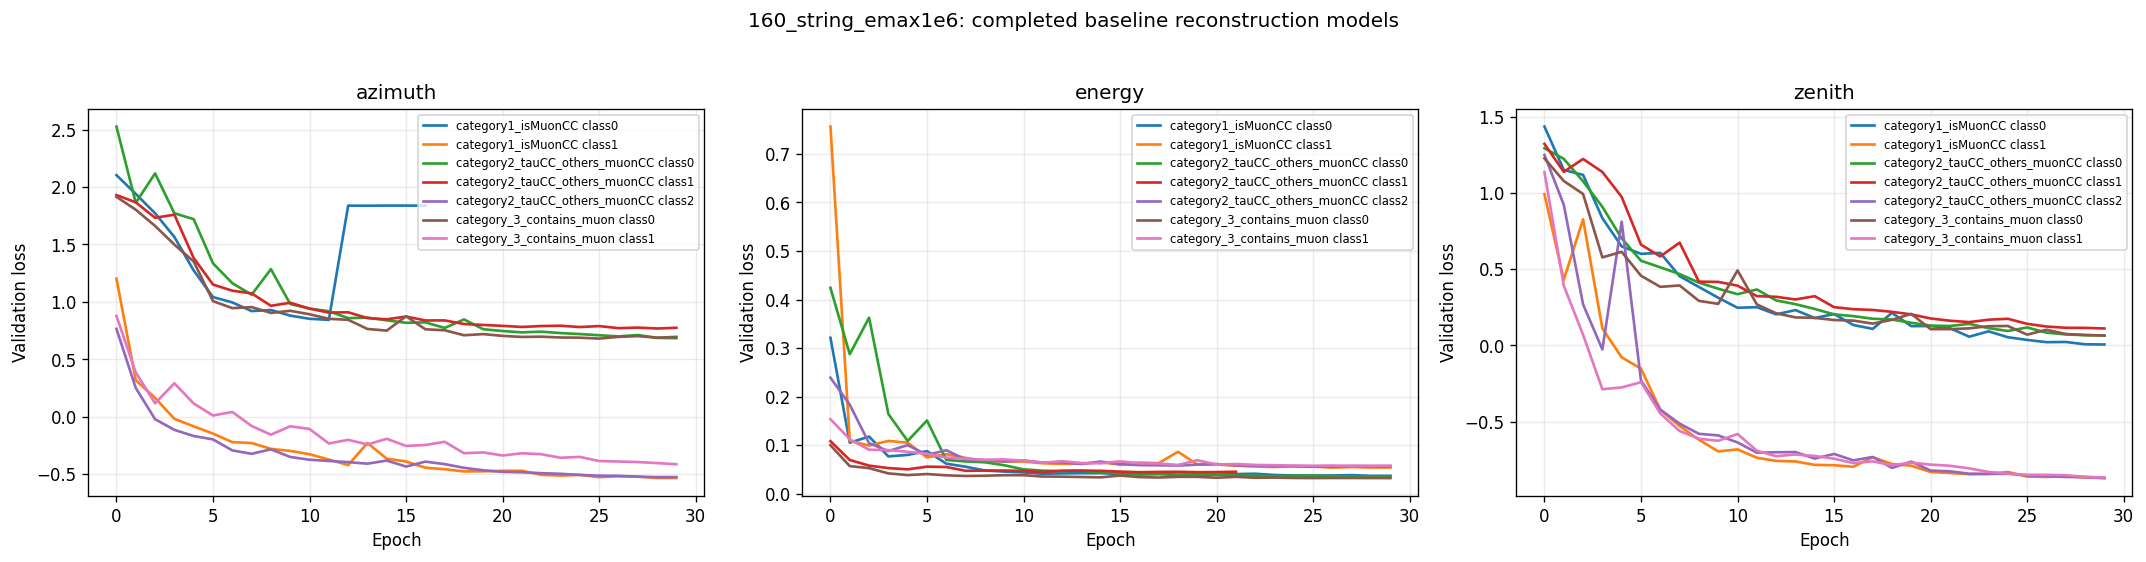

In [14]:
plot_validation_overview(
    geometry="160_string_emax1e6",
    task="reconstruction",
    experiment="baseline",
)

## Example detailed filters

Uncomment and adapt one of these calls after running the cells above.

```python
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="energy")
plot_model_histories(geometry="102_string_emax1e6", task="classification")
plot_model_histories(geometry="160_string_emax1e6", category="category_3_contains_muon")
```

Rerun the status and audit cells after new jobs finish. New trial numbers and completed models will be discovered automatically.

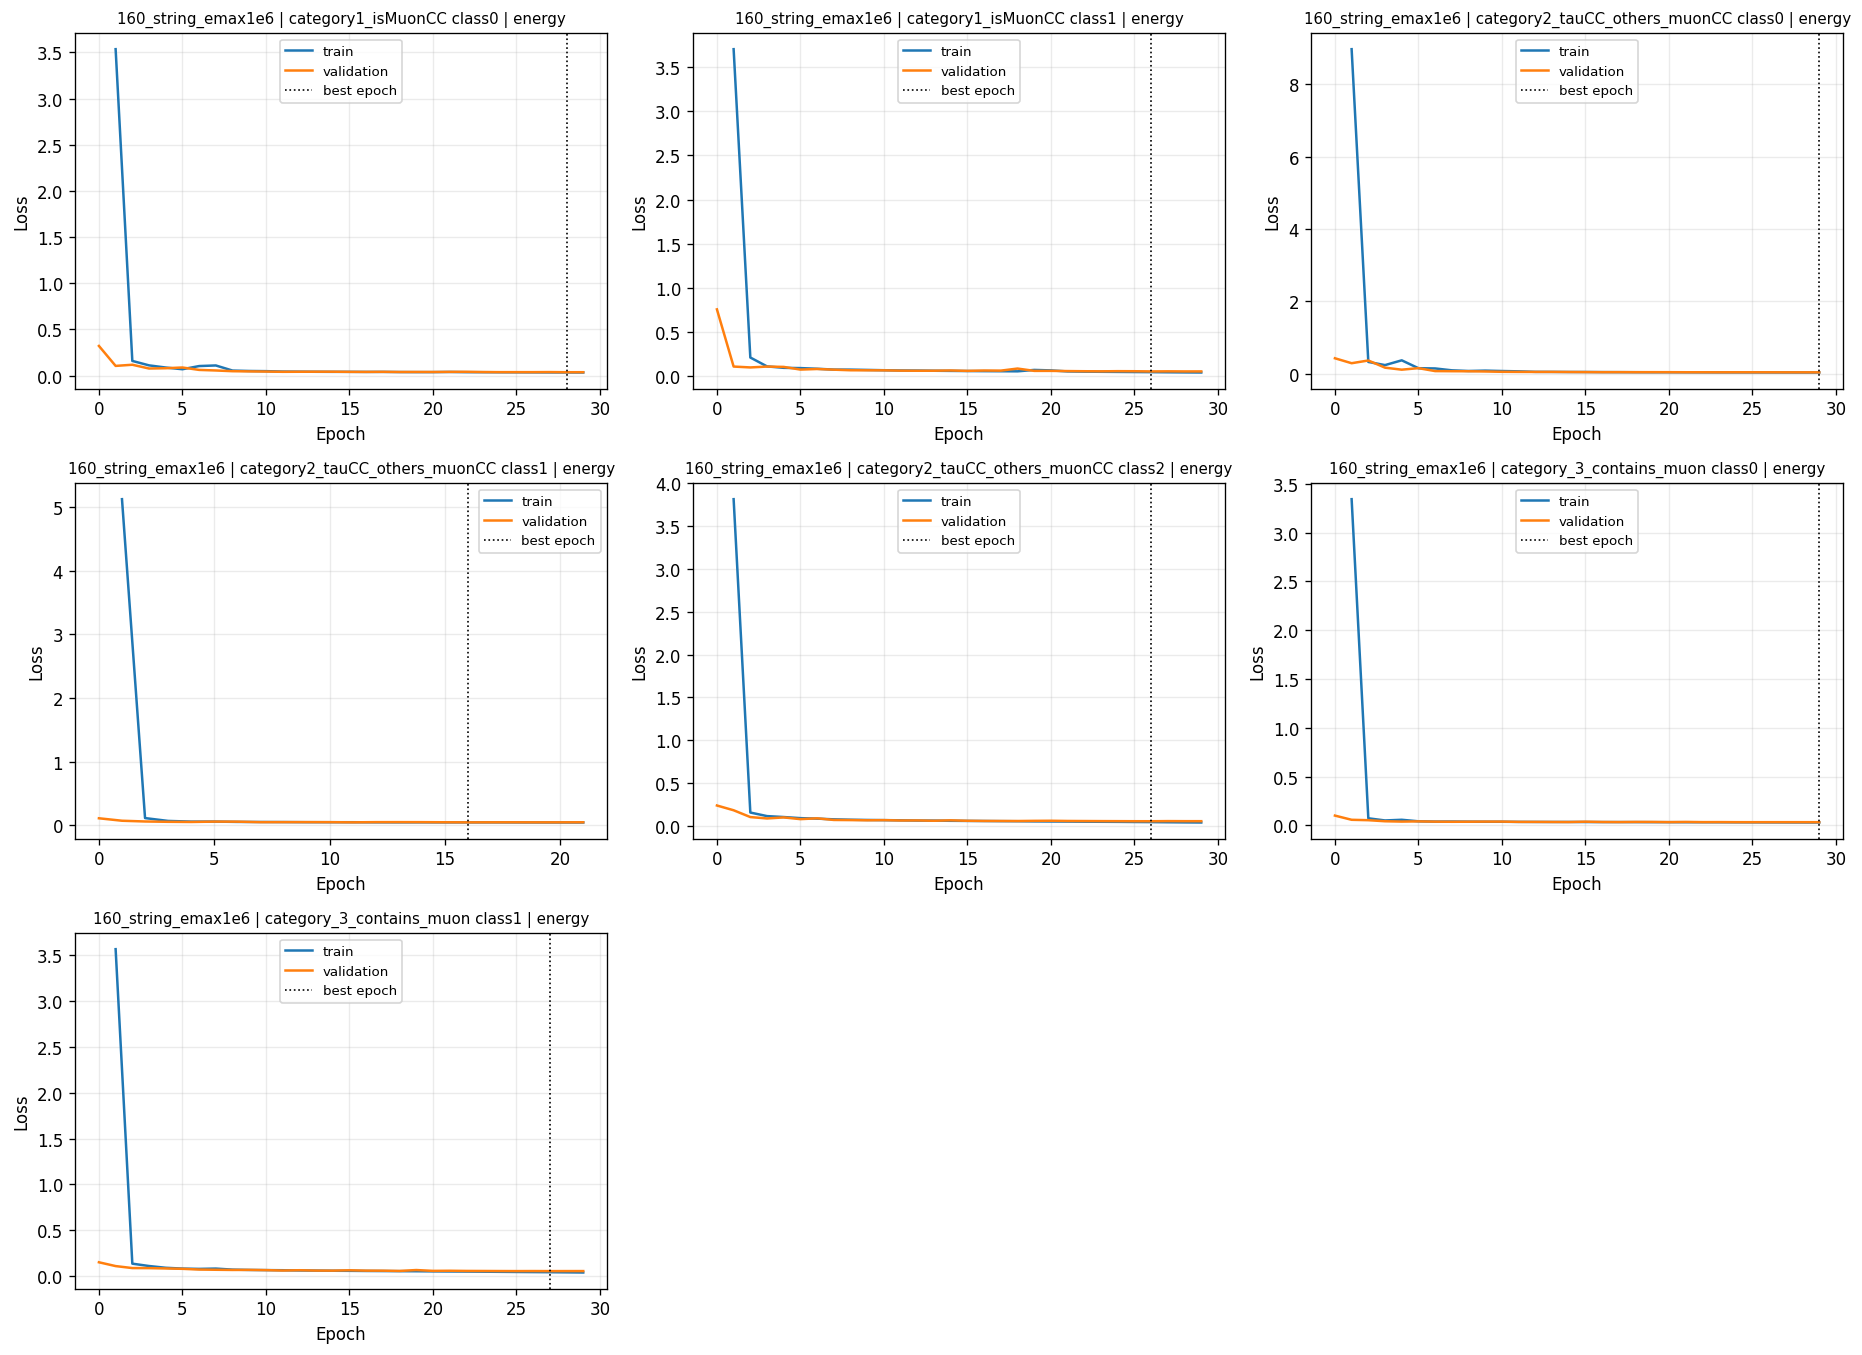

In [15]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="energy")


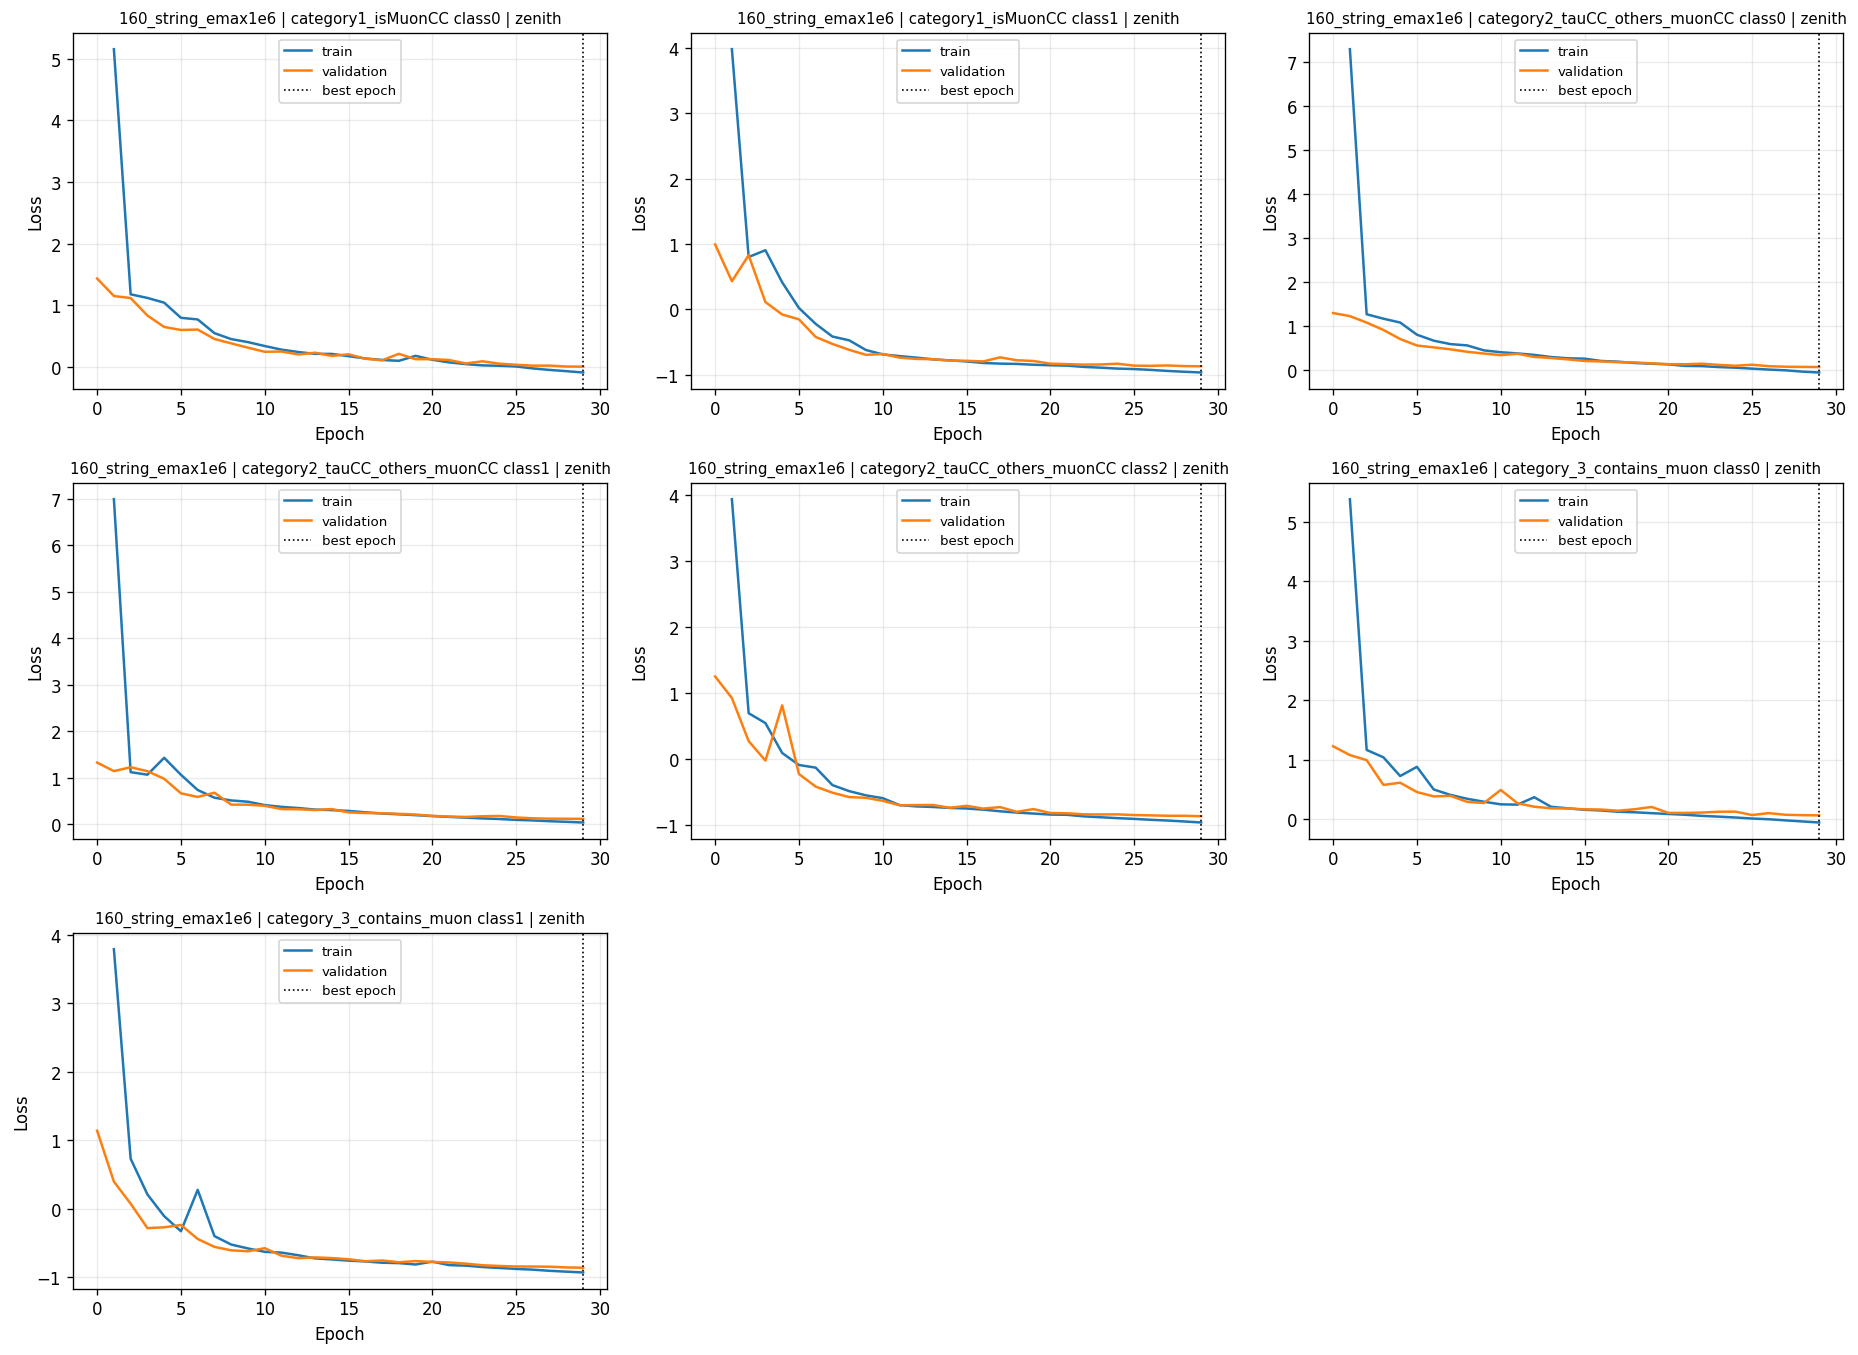

In [16]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="zenith")


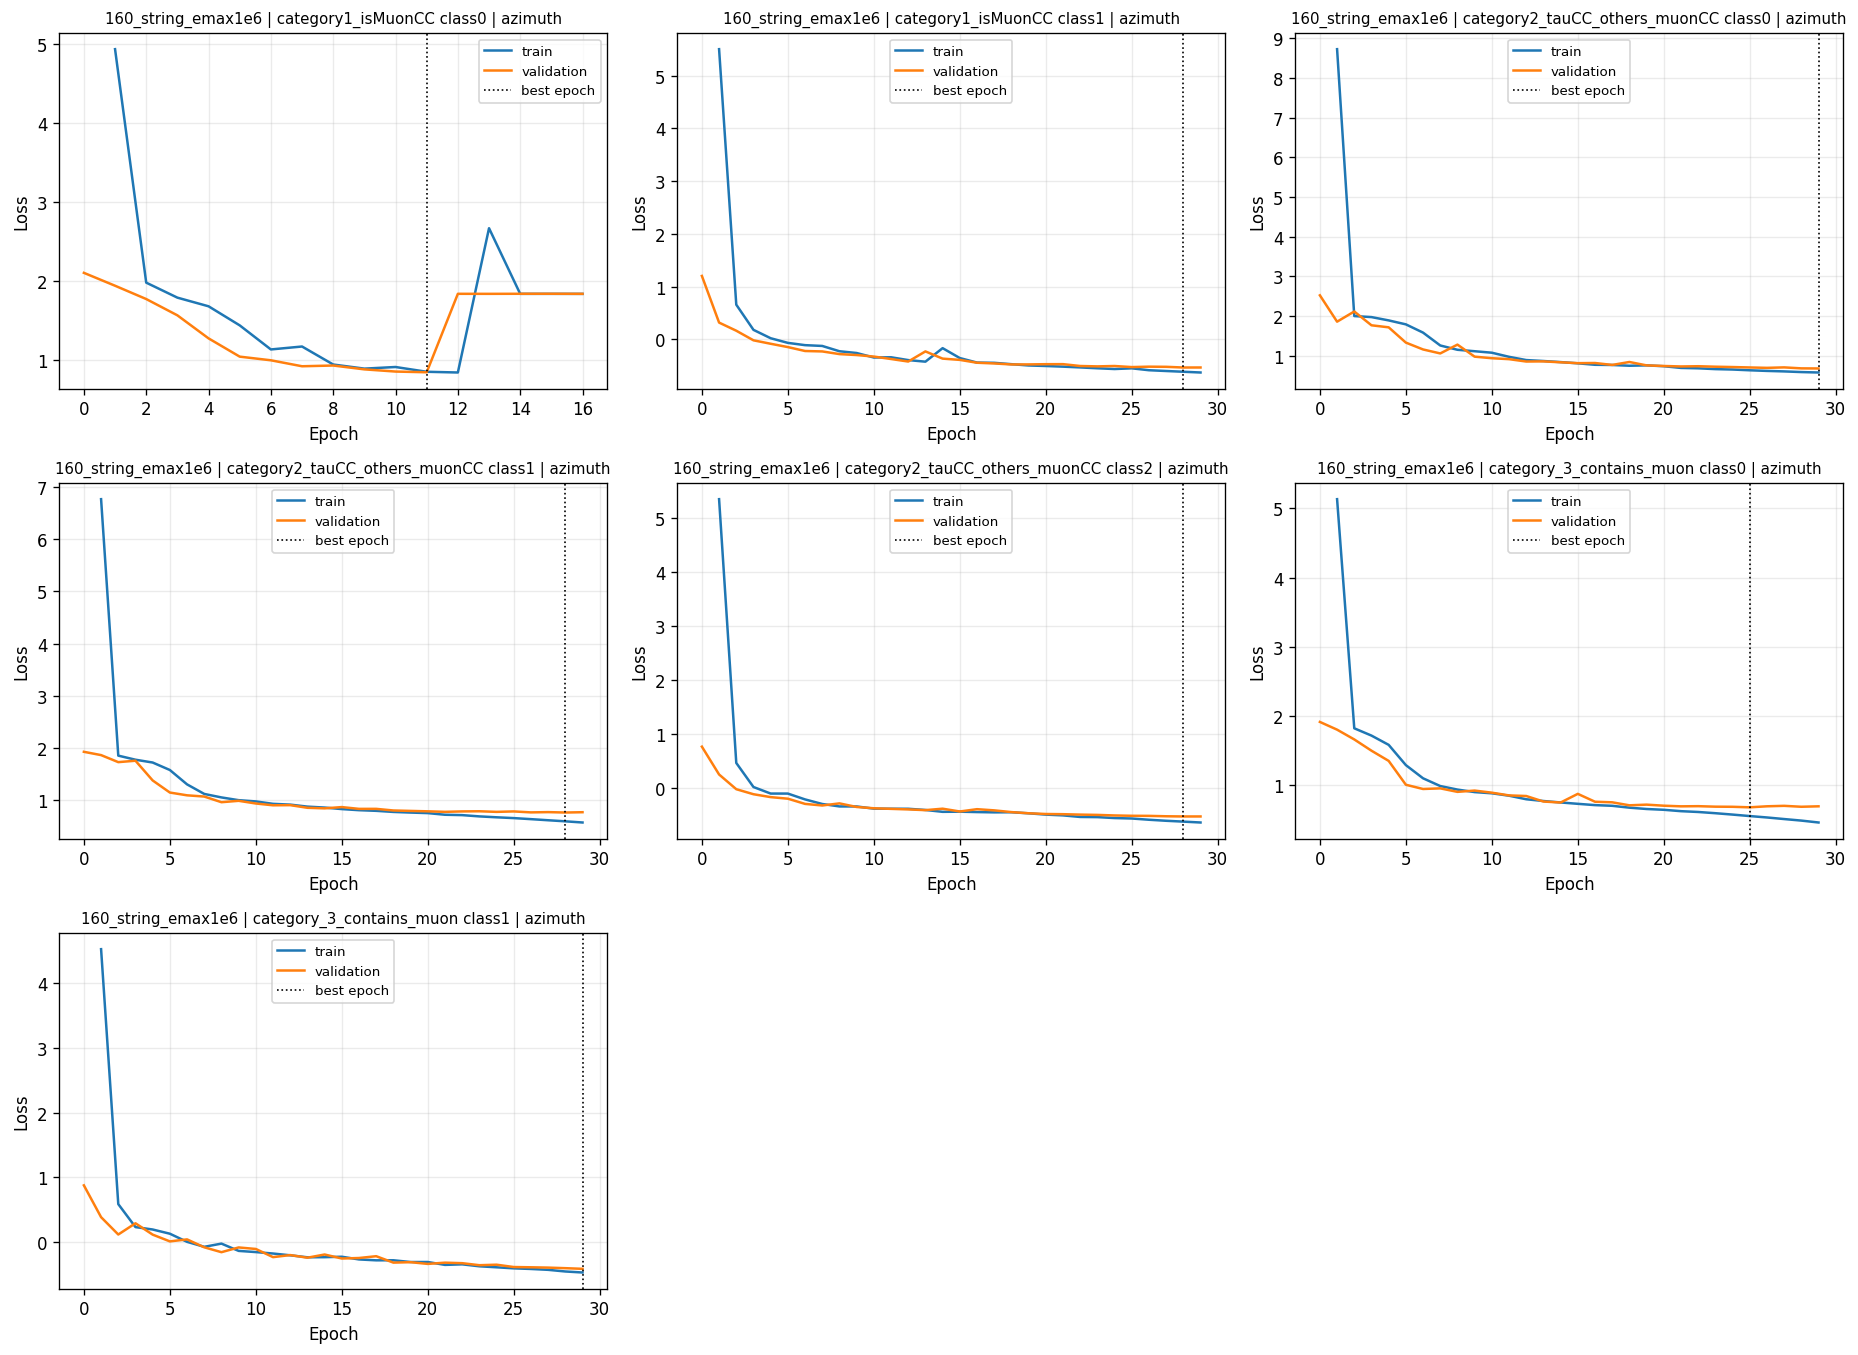

In [17]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="azimuth")
